In [13]:
import pandas as pd
import nltk
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns


#Wordcloud
from wordcloud import WordCloud

In [14]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\SWIFT GO
[nltk_data]     14\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
df = pd.read_csv('reddit_comments_labeled.csv')
df

,post_id,post_title,comment_id,parent_id,author,score,body,clean_text,label
0,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt7sbi,t3_1n5j3y0,throwaway6560192,2169,Maybe they want you to do it as an exercise in...,maybe they want you to do it as an exercise in...,neutral
1,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtc2yj,t3_1n5j3y0,Frission_,681,Maybe the point is to show what vulnerabilitie...,maybe the point is to show what vulnerabilitie...,trust
2,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbt9cor,t3_1n5j3y0,DrShocker,507,Is it concievable they're trying to show you t...,is it concievable they re trying to show you t...,trust
3,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtd4lh,t3_1n5j3y0,COINTELPRO-Relay,432,"Maybe it's some big brain move? Week 1: ""Co...",maybe it s some big brain move week code slop ...,disgust
4,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbtduqf,t3_1n5j3y0,PhilosophicalGoof,101,For a first class assignment? I m guessing thi...,for a first class assignment i m guessing this...,trust
...,...,...,...,...,...,...,...,...,...
329,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ncec38m,t1_ncdgbi4,dragostego,1,"Politely, when you are trying to make the argu...",politely when you are trying to make the argum...,trust
330,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ng3an73,t1_nbye7v5,Ape-Hard,1,Any student who sends you that doesn't care if...,any student who sends you that doesn t care if...,neutral
331,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",nbvoerd,t1_nbvmrp0,Moviesman8,2,That's fair. Thanks for replying.,that s fair thanks for replying,neutral
332,1n5j3y0,"""Vibe Coding"" has now infiltrated college classes",ncejpee,t1_ncec38m,ILLBEON_economy_tool,1,No it’s more that I’m trying to help a bunch o...,no it s more that i m trying to help a bunch o...,anticipation


In [16]:
df_selected = df[['clean_text','label']]
df_selected.head()

,clean_text,label
0,maybe they want you to do it as an exercise in...,neutral
1,maybe the point is to show what vulnerabilitie...,trust
2,is it concievable they re trying to show you t...,trust
3,maybe it s some big brain move week code slop ...,disgust
4,for a first class assignment i m guessing this...,trust


In [ ]:
#Preprocessing Data
#stopwords dari nltk
nltk_stop = set(stopwords.words('english'))

#stoplist lokal
#Stoplist inggris didapatkan dari https://countwordsfree.com/stopwords
with open ('stop_words_english.txt', encoding='utf-8') as f:
    custom_stop = set([w.strip() for w in f.readlines()])

# gabungkan semua stopwords
all_stopwords = nltk_stop.union(custom_stop)
len(all_stopwords)

873

In [ ]:
#Kamus Singkatan (abbreviation)
# Slang didapat dari https://www.kaggle.com/datasets/gowrishankarp/chat-slang-abbreviations-acronyms
abbr = pd.read_csv('slang.csv',header=None, names=['acronym','expansion'])
abbr

,acronym,expansion
NaN,acronym,expansion
0.0,2day,today
1.0,2m2h,too much too handle
2.0,2moro,tomorrow
3.0,2nite,tonight
...,...,...
3352.0,yw,you are welcome
3353.0,ywca,young womens christian association
3354.0,ywimc,your wish is my command
3355.0,ywsyls,you win some you lose some


In [19]:
#Convert Singkatan Menjadi Dictionary
abbr_dict = dict(zip(abbr['acronym'], abbr['expansion']))
abbr_dict

{'acronym': 'expansion',
 '2day': 'today',
 '2m2h': 'too much too handle',
 '2moro': 'tomorrow',
 '2nite': 'tonight',
 '4eae': 'for ever and ever',
 'aaf': 'always and forever',
 'aar': 'at any rate',
 'aayf': 'as always your friend',
 'abd': 'already been done',
 'ack': 'acknowledge',
 'adih': 'another day in hell',
 'adn': 'any day now',
 'adr': 'all due respect',
 'aeap': 'as early as possible',
 'afaic': 'as far as i am concerned',
 'afaik': 'as far as i know',
 'aka': 'also known as',
 'ama': 'ask me anything against medical advice',
 'ambw': 'all my best wishes',
 'aml': 'all my love',
 'aota': 'all of the above',
 'asap': 'as soon as possible',
 'atb': 'all the best',
 'ateotd': 'at the end of the day',
 'atm': 'at the moment automated teller machine ',
 'awol': 'absent without leave',
 'aydy': 'are you done yet',
 'ayec': 'at your earliest convenience',
 'ayor': 'at your own risk',
 'ays': 'are you serious',
 'aysos': 'are you stupid or something',
 'ayt': 'are you there',
 'b/

In [20]:
#Fungsi Preprocessing
def preprocess_text(text):
  tokens = text.split() #Tokenisasi
  #Ganti Singkatan
  tokens = [abbr_dict.get(tok, tok) for tok in tokens] #tok --> Singkatan Token
  #Hapus stopwords
  tokens = [tok for tok in tokens if tok not in all_stopwords]
  #Gabungkan kembali menjadi kalimat
  return ' '.join(tokens)

In [21]:
df['clean_text_processed'] = df['clean_text'].apply(preprocess_text)
df[['clean_text', 'clean_text_processed', 'label']].head()

,clean_text,clean_text_processed,label
0,maybe they want you to do it as an exercise in...,time out information technology authors note e...,neutral
1,maybe the point is to show what vulnerabilitie...,point time out vulnerabilities artificial inte...,trust
2,is it concievable they re trying to show you t...,information technology concievable time out fa...,trust
3,maybe it s some big brain move week code slop ...,information technology big brain week code slo...,disgust
4,for a first class assignment i m guessing this...,class assignment guessing time out information...,trust


In [22]:
# Fungsi bantu untuk membuat wordcloud dari subset data
def generate_wordcloud(text_series, title):
    text = " ".join(text_series)
    wc = WordCloud(
        width=800,
        height=400,
        background_color="white",
        collocations=False
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")
    plt.title(title)
    plt.show()

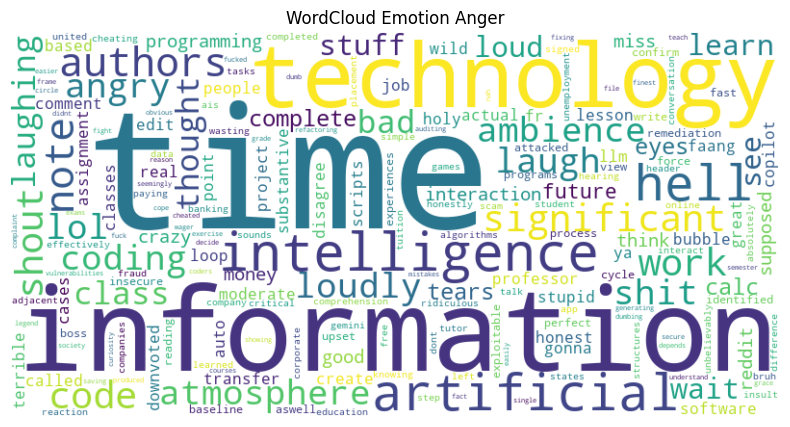

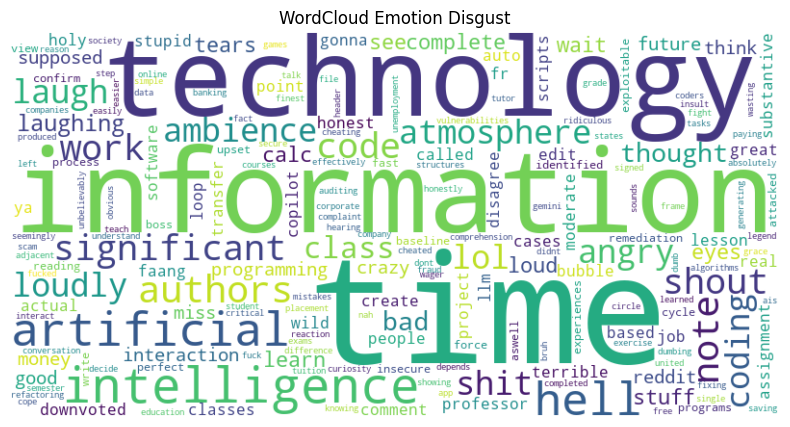

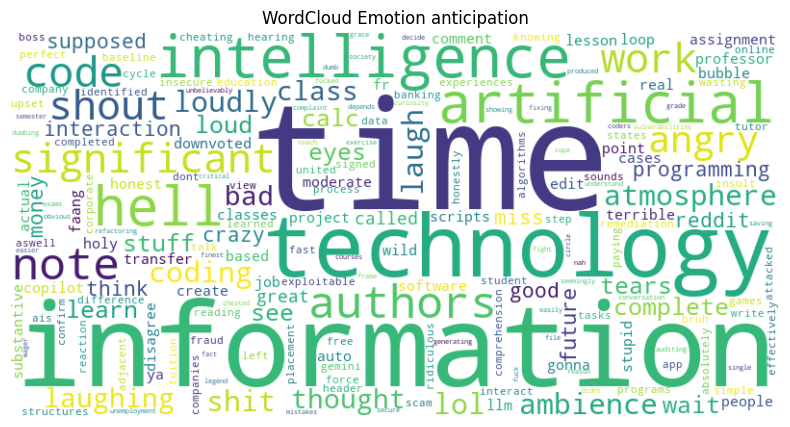

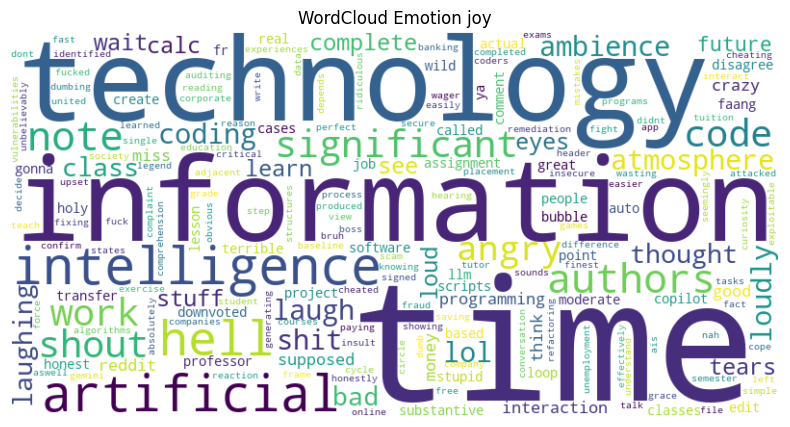

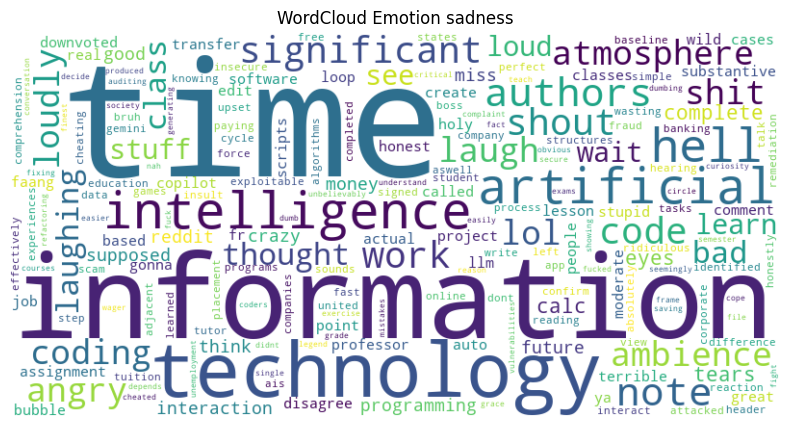

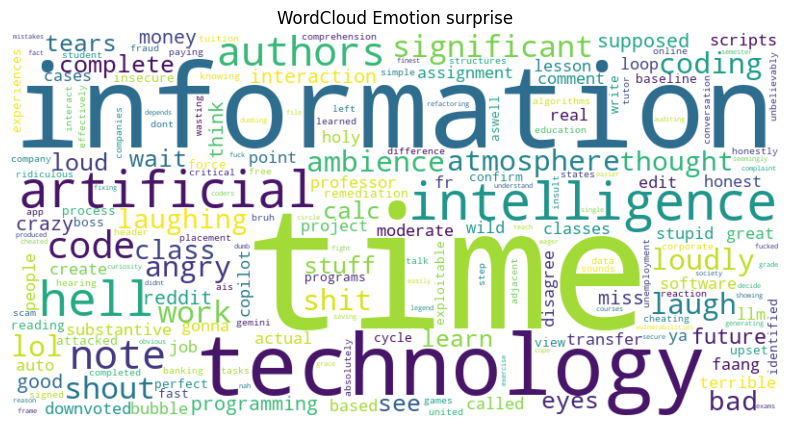

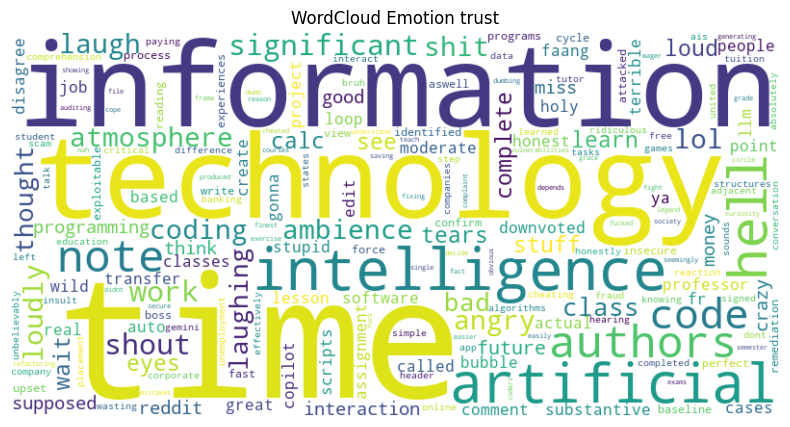

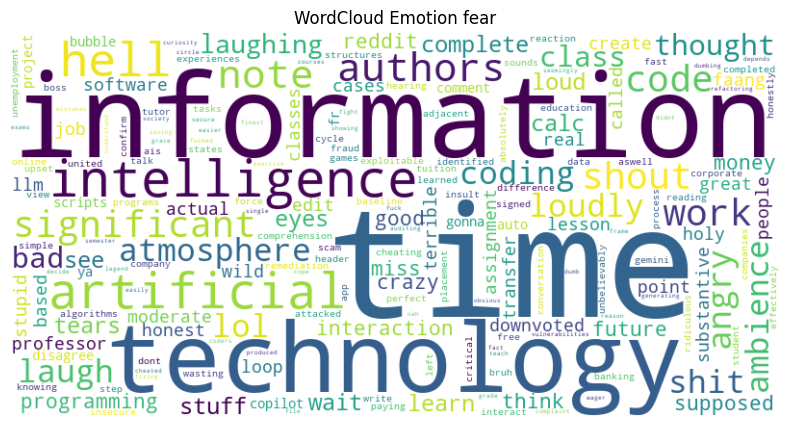

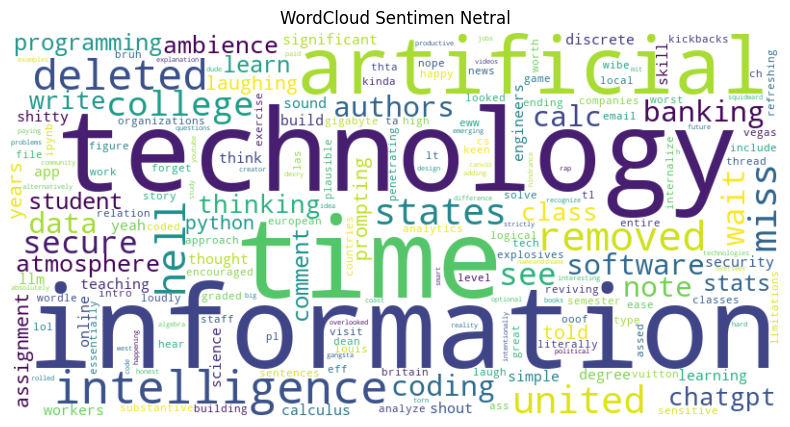

In [23]:
anger_text = df[df['label'] == 'anger']['clean_text_processed']
generate_wordcloud(anger_text, "WordCloud Emotion Anger")

disgust_text = df[df['label'] == 'disgust']['clean_text_processed']
generate_wordcloud(anger_text, "WordCloud Emotion Disgust")

anticipation_text = df[df['label'] == 'anticipation']['clean_text_processed']
generate_wordcloud(anger_text, "WordCloud Emotion anticipation")

joy_text = df[df['label'] == 'joy']['clean_text_processed']
generate_wordcloud(anger_text, "WordCloud Emotion joy")

sadness_text = df[df['label'] == 'sadness']['clean_text_processed']
generate_wordcloud(anger_text, "WordCloud Emotion sadness")

surprise_text = df[df['label'] == 'surprise']['clean_text_processed']
generate_wordcloud(anger_text, "WordCloud Emotion surprise")

trust_text = df[df['label'] == 'trust']['clean_text_processed']
generate_wordcloud(anger_text, "WordCloud Emotion trust")

fear_text = df[df['label'] == 'fear']['clean_text_processed']
generate_wordcloud(anger_text, "WordCloud Emotion fear")

neutral_text = df[df['label'] == 'neutral']['clean_text_processed']
generate_wordcloud(neutral_text, "WordCloud Sentimen Netral")


In [24]:
#Lakukan Proses TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2
)

X = vectorizer.fit_transform(df['clean_text_processed'])
y = df['label']


In [25]:
#Buat Training / Test Split 80 banding 20
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [26]:
#SVM Training (Linear SVC)
model = LinearSVC()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

Akurasi: 0.44776119402985076

=== Classification Report ===
              precision    recall  f1-score   support

       anger       0.50      0.12      0.20         8
anticipation       0.28      0.36      0.31        14
     disgust       0.00      0.00      0.00         2
        fear       0.50      0.33      0.40         3
         joy       1.00      0.33      0.50         3
     neutral       0.53      0.56      0.55        16
     sadness       0.00      0.00      0.00         1
    surprise       0.00      0.00      0.00         1
       trust       0.50      0.68      0.58        19

    accuracy                           0.45        67
   macro avg       0.37      0.27      0.28        67
weighted avg       0.45      0.45      0.42        67



c:\dev\python\analisis_emosi\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\dev\python\analisis_emosi\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\dev\python\analisis_emosi\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0]

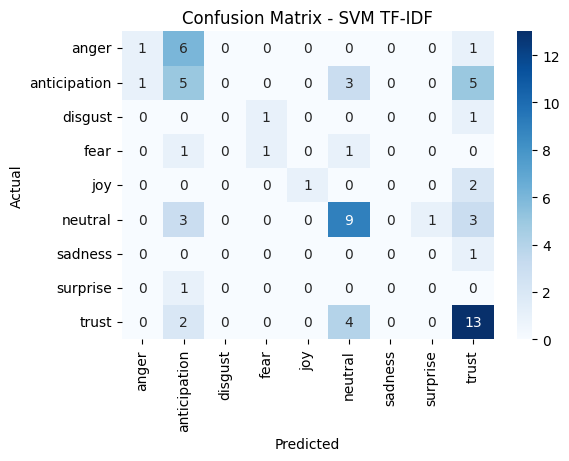

In [27]:
#Evaluasi Model
y_pred = model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=model.classes_,
            yticklabels=model.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM TF-IDF')
plt.show()

In [28]:
sample_text = [
    "Fuck ai, vibe coding is shit",
    "I like vibe coding, vibe coding helps me to build a project faster",
    "idk, maybe vibe coding is not so helpful for me. I prefer code by myself"
]

sample_vec = vectorizer.transform(sample_text)
preds = model.predict(sample_vec)

for t, p in zip(sample_text, preds):
    print(f"{t} --> {p}")

Fuck ai, vibe coding is shit --> anger
I like vibe coding, vibe coding helps me to build a project faster --> neutral
idk, maybe vibe coding is not so helpful for me. I prefer code by myself --> trust
